## Explanatory Data Analysis on Transactions Sale for Real Estate in KSA 

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from PIL import Image
import arabic_reshaper
from bidi.algorithm import get_display

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Read CSV File

In [6]:
df = pd.read_csv("../dataset/Transactions sale for real estate.csv")
df.head()

,المنطقة,المدينة,المدينة / الحي,الرقم المرجعي للصفقة,تاريخ الصفقة ميلادي,تاريخ الصفقة هجري,تصنيف العقار,عدد العقارات,السعر,المساحة
0,منطقة مكة المكرمه,الطائف,الطائف/ حي البوادي,30416650,2025/07/01,1447/01/06,سكني,1,"240,000",630.00
1,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,30417354,2025/07/01,1447/01/06,سكني,1,"1,000,000","1,652.36"
2,منطقة الرياض,الرياض,الرياض/الصحافة,30427896,2025/07/01,1447/01/06,تجاري,2,"63,000,000","1,800.00"
3,منطقة الرياض,الرياض,الرياض/بدر,30418087,2025/07/01,1447/01/06,تجاري,1,"2,415,000","1,050.00"
4,منطقة الرياض,الرياض,الرياض/الشفاء,30422608,2025/07/01,1447/01/06,سكني,1,"2,000,000",875.00


Column Renaming to English

In [8]:
df.rename(columns={
    "المنطقة": "Region",
    "المدينة": "City",
    "المدينة / الحي": "City / District",
    "الرقم المرجعي للصفقة": "Ref. Number of Transaction",
    "تاريخ الصفقة ميلادي": "Greg. Date of Transaction",
    "تاريخ الصفقة هجري": "Hijri Date of Transaction",
    "تصنيف العقار": "Property Type",
    "عدد العقارات": "Number of Properties",
    "السعر": "Price",
    "المساحة": "Area",
}, inplace=True)

df.columns

Index(['Region', 'City', 'City / District', 'Ref. Number of Transaction',
       'Greg. Date of Transaction', 'Hijri Date of Transaction',
       'Property Type', 'Number of Properties', 'Price', 'Area'],
      dtype='str')

Save the updated dataset with renamed columns

In [18]:
df.to_csv("../dataset/Transactions_sale_for_real_estate_renamed.csv", index=False)
df.head()

,Region,City,City / District,Ref. Number of Transaction,Greg. Date of Transaction,Hijri Date of Transaction,Property Type,Number of Properties,Price,Area
0,منطقة مكة المكرمه,الطائف,الطائف/ حي البوادي,30416650,2025/07/01,1447/01/06,سكني,1,"240,000",630.00
1,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,30417354,2025/07/01,1447/01/06,سكني,1,"1,000,000","1,652.36"
2,منطقة الرياض,الرياض,الرياض/الصحافة,30427896,2025/07/01,1447/01/06,تجاري,2,"63,000,000","1,800.00"
3,منطقة الرياض,الرياض,الرياض/بدر,30418087,2025/07/01,1447/01/06,تجاري,1,"2,415,000","1,050.00"
4,منطقة الرياض,الرياض,الرياض/الشفاء,30422608,2025/07/01,1447/01/06,سكني,1,"2,000,000",875.00


### Dataset Overview

In [19]:
# Basic shape of the dataset
print(df.shape, "\n")

# Column names and data types
print(df.info())

(48820, 10) 

<class 'pandas.DataFrame'>
RangeIndex: 48820 entries, 0 to 48819
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Region                      48820 non-null  str  
 1   City                        48820 non-null  str  
 2   City / District             48820 non-null  str  
 3   Ref. Number of Transaction  48820 non-null  int64
 4   Greg. Date of Transaction   48820 non-null  str  
 5   Hijri Date of Transaction   48820 non-null  str  
 6   Property Type               48820 non-null  str  
 7   Number of Properties        48820 non-null  int64
 8   Price                       48820 non-null  str  
 9   Area                        48820 non-null  str  
dtypes: int64(2), str(8)
memory usage: 3.7 MB
None


### Descriptive Statistics

In [20]:
# Summary statistics for numerical columns
df.describe()

,Ref. Number of Transaction,Number of Properties
count,4.882000e+04,48820.000000
mean,3.138768e+07,1.019398
std,5.715977e+05,0.349365
min,2.742950e+07,1.000000
25%,3.088808e+07,1.000000
50%,3.138633e+07,1.000000
75%,3.189065e+07,1.000000
max,3.237820e+07,22.000000


In [24]:
# Summary statistics for all columns, including categorical ones
df.describe(include="all")

,Region,City,City / District,Ref. Number of Transaction,Greg. Date of Transaction,Hijri Date of Transaction,Property Type,Number of Properties,Price,Area
count,48820,48820,48820,4.882000e+04,48820,48820,48820,48820.000000,48820,48820
unique,13,156,4352,NaN,92,92,3,NaN,9294,16858
top,منطقة مكة المكرمه,جده,الرياض/الجنادرية,NaN,2025/07/09,1447/01/14,سكني,NaN,"100,000",600.00
freq,13202,7803,1514,NaN,1242,1242,44232,NaN,1620,1818
mean,NaN,NaN,NaN,3.138768e+07,NaN,NaN,NaN,1.019398,NaN,NaN
std,NaN,NaN,NaN,5.715977e+05,NaN,NaN,NaN,0.349365,NaN,NaN
min,NaN,NaN,NaN,2.742950e+07,NaN,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,3.088808e+07,NaN,NaN,NaN,1.000000,NaN,NaN
50%,NaN,NaN,NaN,3.138633e+07,NaN,NaN,NaN,1.000000,NaN,NaN
75%,NaN,NaN,NaN,3.189065e+07,NaN,NaN,NaN,1.000000,NaN,NaN


### Missing Values Analysis

In [28]:
# Number of missing values per column
if(df.isna().sum().any()):
    print("Missing values per column:")
    print(df.isna().sum())
else:
    print("No missing values in the dataset.")

No missing values in the dataset.


### Duplicate Records

In [30]:
# Number of duplicate rows
if(df.duplicated().sum() > 0):
    print(f"Number of duplicate rows: {df.duplicated().sum()}")
else:
    print("No duplicate rows in the dataset.")

No duplicate rows in the dataset.


### Categorical Columns Exploration

In [51]:
# Understand distributions of non-numeric features (e.g. city, district, property type).
categorical_cols = df.select_dtypes(include=["object"]).columns

C:\Users\nadaf\AppData\Local\Temp\ipykernel_47124\3489284824.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [59]:
for i, col in enumerate(categorical_cols, 1):
    print(f"\n{i}: {col}")
    display(
        df[col]
        .value_counts()
        .head(10)
        .reset_index()
        .rename(columns={"index": col, col: "count"})
    )


1: Region


,count,count
0,منطقة مكة المكرمه,13202
1,منطقة الرياض,11117
2,منطقة الشرقية,7332
3,منطقة المدينة المنوره,3647
4,منطقة القصيم,3021
5,منطقة حائل,2743
6,منطقة عسير,2478
7,منطقة تبوك,1373
8,منطقة جازان,1247
9,منطقة الجوف,780



2: City


,count,count
0,جده,7803
1,الرياض,7235
2,المدينة المنورة,3268
3,الطائف,2316
4,مكة المكرمة,2048
5,حائل,1556
6,الدمام,1345
7,الخبر,1237
8,بريده,1206
9,تبوك,1202



3: City / District


...

,count,count
0,سكني,44232
1,تجاري,3155
2,زراعي,1433



7: Price


,count,count
0,"100,000",1620
1,"200,000",1195
2,"10,000",1029
3,"500,000",1016
4,"266,478",998
5,"50,000",990
6,"300,000",974
7,"1,000,000",939
8,"400,000",939
9,"20,000",810



8: Area


,count,count
0,600.00,1818
1,375.00,1544
2,400.00,1437
3,500.00,1184
4,300.00,982
5,630.00,923
6,450.00,809
7,625.00,711
8,900.00,701
9,312.50,629


### Numerical Columns Exploration

In [60]:
# Spot ranges, skewness, and outliers.
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['Ref. Number of Transaction', 'Number of Properties'], dtype='str')

### Distribution Plots

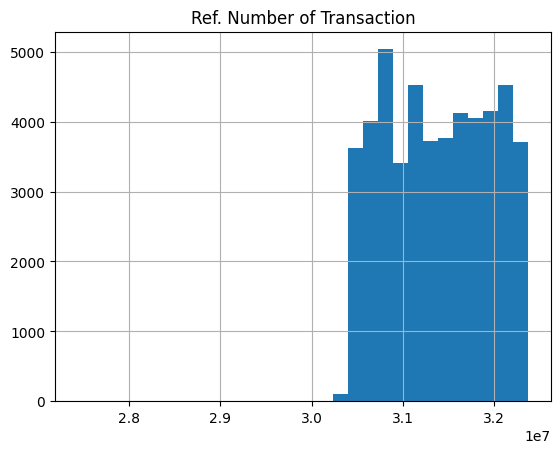

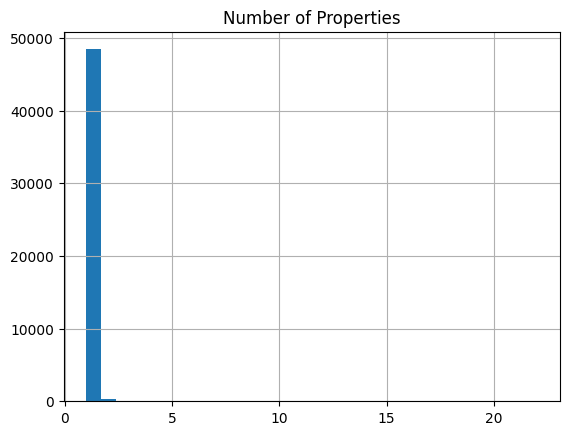

In [62]:
# Visualize data spread and skewness.
for col in numerical_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

### Outlier Detection (Boxplots)

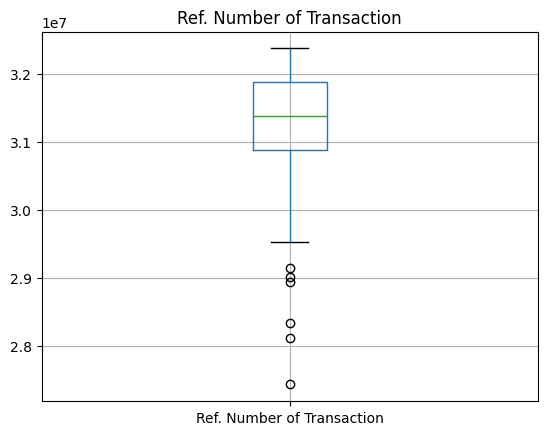

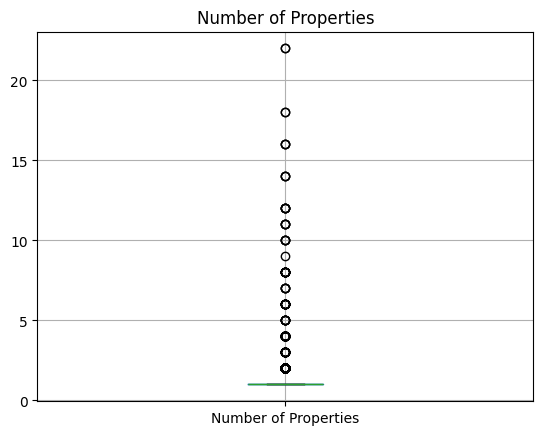

In [63]:
# Identify extreme values (very important for real estate).
for col in numerical_cols:
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

### Correlation Analysis

In [64]:
# Understand relationships between numeric variables.
df[numerical_cols].corr()

,Ref. Number of Transaction,Number of Properties
Ref. Number of Transaction,1.000000,-0.007375
Number of Properties,-0.007375,1.000000


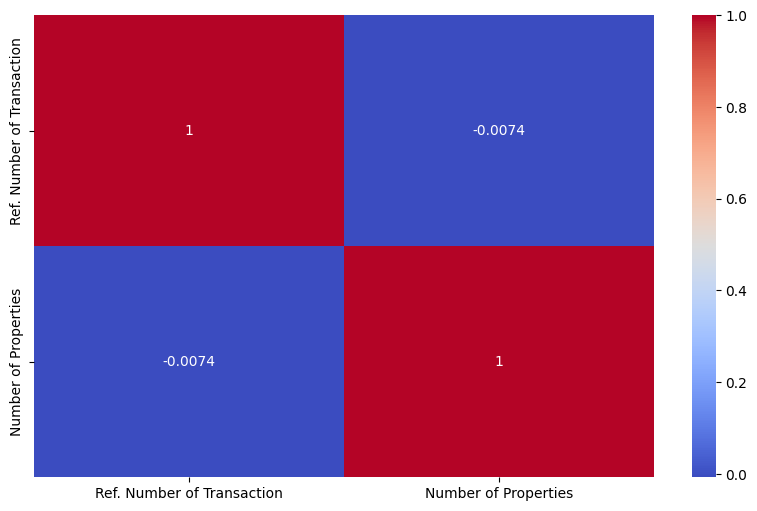

In [67]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

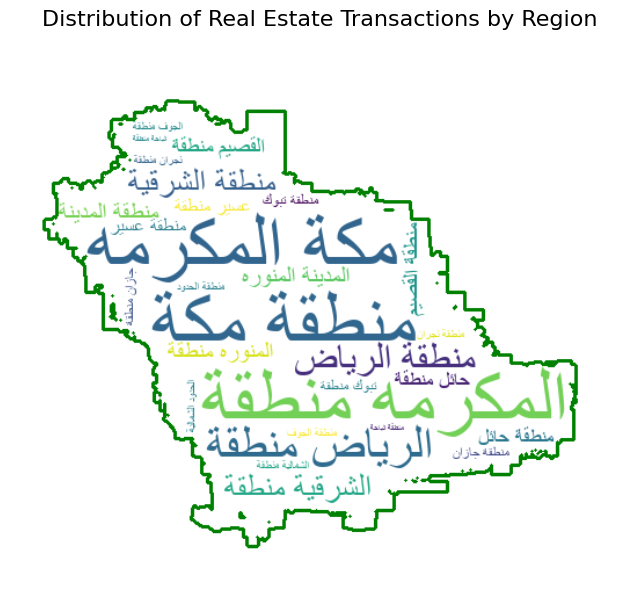

In [85]:
arabic_text = " ".join(df["Region"].astype(str))
reshaped_text = arabic_reshaper.reshape(arabic_text)
bidi_text = get_display(reshaped_text)

wordcloud = WordCloud(
    background_color="white",
    mask=mask,
    contour_width=2,
    contour_color="green",
    font_path="arial.ttf"
).generate(bidi_text)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Distribution of Real Estate Transactions by Region", fontsize=16)
plt.axis("off")
plt.show()

wordcloud.to_file("../images/region_wordcloud.png")


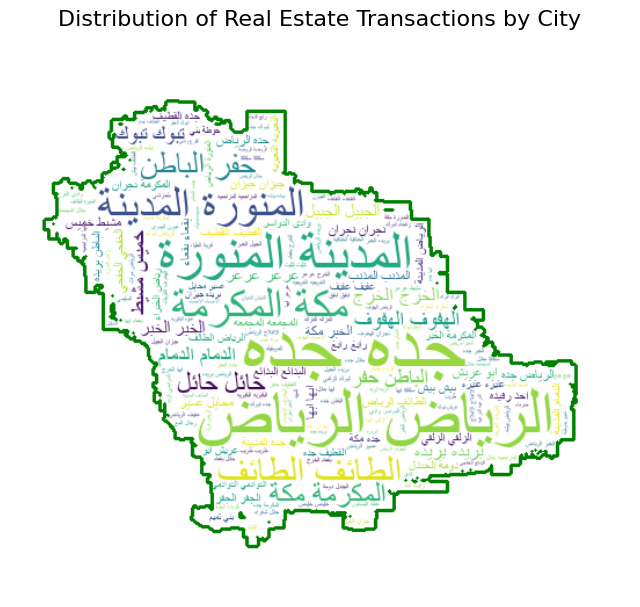

In [86]:
arabic_text = " ".join(df["City"].astype(str))
reshaped_text = arabic_reshaper.reshape(arabic_text)
bidi_text = get_display(reshaped_text)

wordcloud = WordCloud(
    background_color="white",
    mask=mask,
    contour_width=2,
    contour_color="green",
    font_path="arial.ttf"
).generate(bidi_text)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Distribution of Real Estate Transactions by City", fontsize=16)
plt.axis("off")
plt.show()

wordcloud.to_file("../images/city_wordcloud.png")